# Credit Card Fraud Detection - ML Term Project
**Course:** ITCS 494: Machine Learning  
**University of Bahrain**

Zahra Mohamed Abdulla 202203702

Zainab Mohamed Moosa 202205075

## Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

from sklearn.model_selection import GridSearchCV



## Step 2: Load and Explore the Dataset

In [ ]:
# Load the dataset
# Make sure 'creditcard.csv' is in the same folder as this notebook
df = pd.read_csv('creditcard.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print('=== Dataset Info ===')
df.info()

print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Check for missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ')

=== Missing Values ===
No missing values found 


=== Class Distribution ===
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


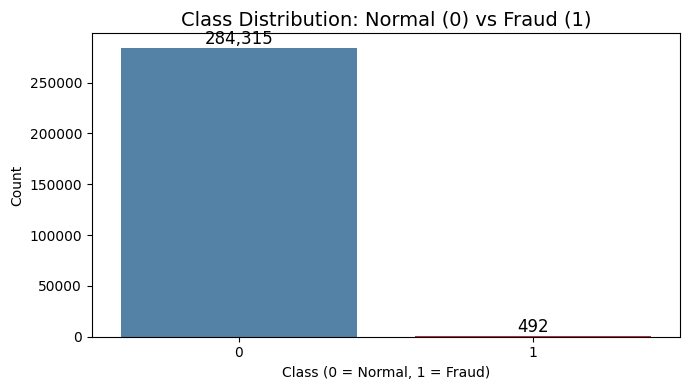


  The dataset is highly imbalanced. We will use SMOTE to fix this.


In [ ]:
# Check class distribution (Fraud vs Normal)
print('=== Class Distribution ===')
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

# Visualize class distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Class Distribution: Normal (0) vs Fraud (1)', fontsize=14)
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

print('\n  The dataset is highly imbalanced. We will use SMOTE to fix this.')

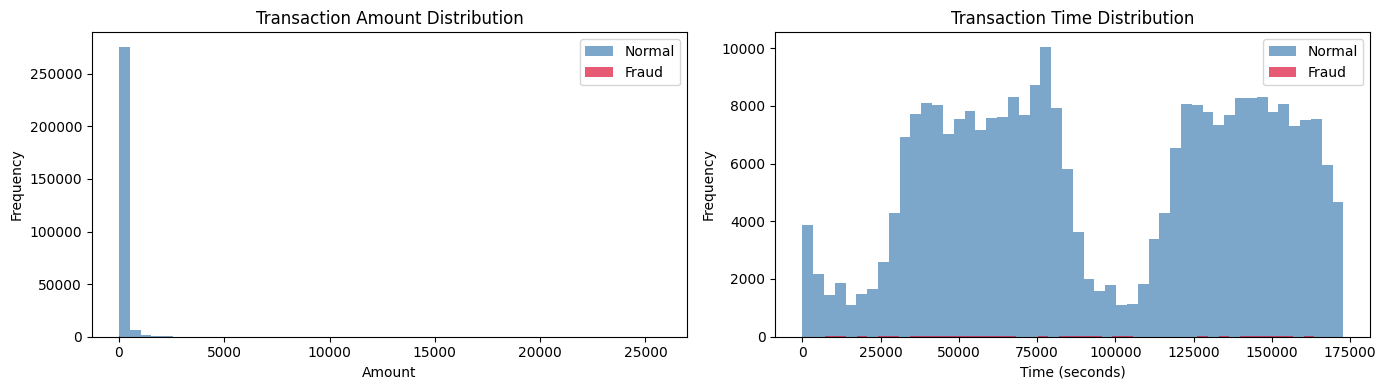

In [ ]:
# Distribution of transaction amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=50, color='crimson', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Time distribution
axes[1].hist(df[df['Class'] == 0]['Time'], bins=50, color='steelblue', alpha=0.7, label='Normal')
axes[1].hist(df[df['Class'] == 1]['Time'], bins=50, color='crimson', alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

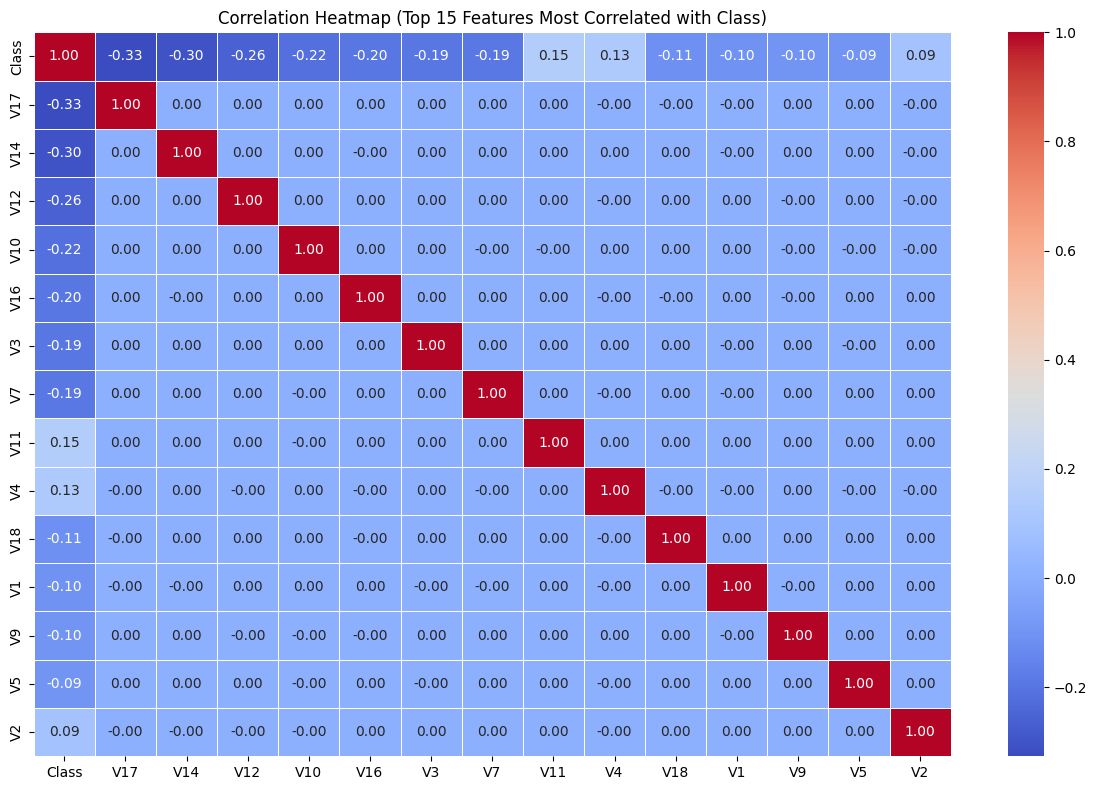

In [ ]:
# Correlation heatmap (top features)
plt.figure(figsize=(12, 8))
corr = df.corr()
# Show correlation with Class
top_corr_features = corr['Class'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Top 15 Features Most Correlated with Class)')
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

In [ ]:
# Feature Scaling
# The 'Amount' and 'Time' features are not scaled like V1-V28 (which are PCA components)
# We apply StandardScaler to normalize them

scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop the original unscaled columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print(' Amount and Time have been scaled.')
print('New columns added: scaled_Amount, scaled_Time')
print('Dataset shape:', df.shape)

 Amount and Time have been scaled.
New columns added: scaled_Amount, scaled_Time
Dataset shape: (284807, 31)


In [ ]:
# Split Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)

Features shape: (284807, 30)
Target shape:   (284807,)


In [ ]:
# Train/Test Split
# 80% training, 20% testing
# stratify=y ensures both sets have the same fraud ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size: ', X_test.shape)
print(f'\nFraud in training set: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'Fraud in testing set:  {y_test.sum()}  ({y_test.mean()*100:.4f}%)')

Training set size: (227845, 30)
Testing set size:  (56962, 30)

Fraud in training set: 394 (0.1729%)
Fraud in testing set:  98  (0.1720%)


=== After SMOTE ===
Resampled training set shape: (454902, 30)
Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


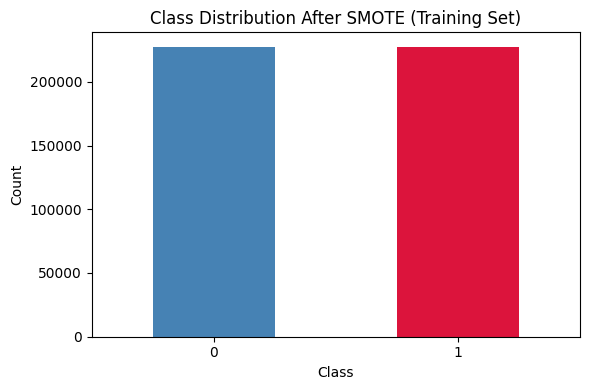

In [ ]:
# Handle Class Imbalance with SMOTE
# SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic fraud samples
# We only apply SMOTE to training data — NEVER to test data

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('=== After SMOTE ===')
print('Resampled training set shape:', X_train_res.shape)
print('Class distribution after SMOTE:')
print(pd.Series(y_train_res).value_counts())

# Visualize
plt.figure(figsize=(6, 4))
pd.Series(y_train_res).value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Class Distribution After SMOTE (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 4: Model Building and Training

Having 4 models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

In [ ]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_test, y_test):

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC AUC   : {roc_auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'y_pred_prob': y_pred_prob
    }

results = []  # Store all results here


  Logistic Regression
  Accuracy  : 0.9743
  Precision : 0.0581
  Recall    : 0.9184
  F1-Score  : 0.1094
  ROC AUC   : 0.9698

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



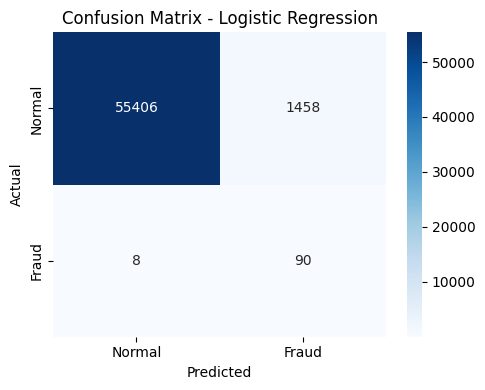

In [ ]:
#  Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

result_lr = evaluate_model('Logistic Regression', lr, X_test, y_test)
results.append(result_lr)


  Decision Tree
  Accuracy  : 0.9836
  Precision : 0.0792
  Recall    : 0.8061
  F1-Score  : 0.1443
  ROC AUC   : 0.8950

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.08      0.81      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.89      0.57     56962
weighted avg       1.00      0.98      0.99     56962



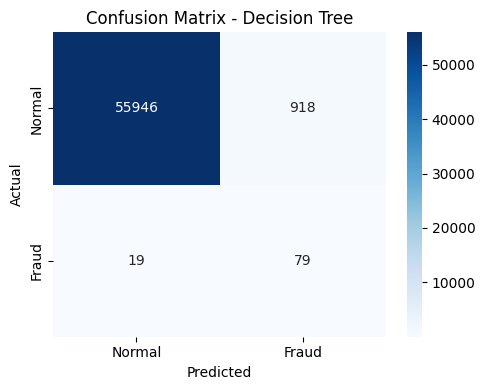

In [ ]:
# Model 2: Decision Tree

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train_res, y_train_res)

result_dt = evaluate_model('Decision Tree', dt, X_test, y_test)
results.append(result_dt)


  Random Forest
  Accuracy  : 0.9994
  Precision : 0.8144
  Recall    : 0.8061
  F1-Score  : 0.8103
  ROC AUC   : 0.9688

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



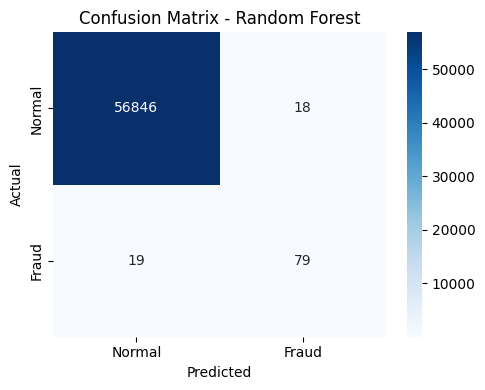

In [ ]:
# Model 3: Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

result_rf = evaluate_model('Random Forest', rf, X_test, y_test)
results.append(result_rf)


  Gradient Boosting
  Accuracy  : 0.9867
  Precision : 0.1055
  Recall    : 0.8980
  F1-Score  : 0.1888
  ROC AUC   : 0.9807

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.11      0.90      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962



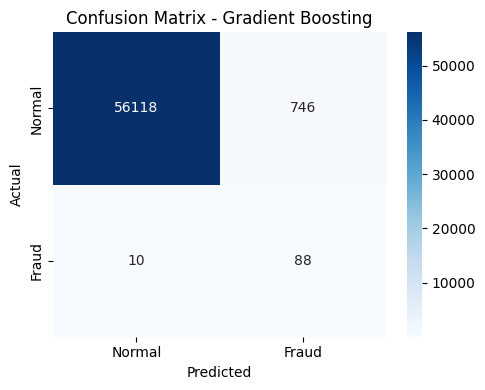

In [ ]:
# Model 4: Gradient Boosting

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_res, y_train_res)

result_gb = evaluate_model('Gradient Boosting', gb, X_test, y_test)
results.append(result_gb)

## Step 5: Hyperparameter Tuning (Random Forest)

In [ ]:
# Hyperparameter Tuning with GridSearchCV
# We tune the Random Forest to find the best combination of hyperparameters.
# This helps improve model performance.

param_grid = {
    'n_estimators': [50],
    'max_depth':    [20, None],
    'min_samples_split': [2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

print(f'\n Best Parameters: {grid_search.best_params_}')
print(f'Best F1 Score (CV): {grid_search.best_score_:.4f}')

Fitting 2 folds for each of 2 candidates, totalling 4 fits

 Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 Score (CV): 0.9998



  Random Forest (Tuned)
  Accuracy  : 0.9994
  Precision : 0.8438
  Recall    : 0.8265
  F1-Score  : 0.8351
  ROC AUC   : 0.9649

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.84      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



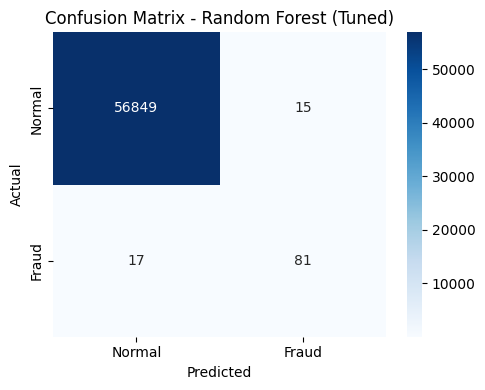

In [ ]:
# Evaluate the tuned model
best_rf = grid_search.best_estimator_
result_best_rf = evaluate_model('Random Forest (Tuned)', best_rf, X_test, y_test)
results.append(result_best_rf)

## Step 6: Model Comparison

In [ ]:
# Summary Table
results_df = pd.DataFrame([{
    'Model':     r['Model'],
    'Accuracy':  round(r['Accuracy'],  4),
    'Precision': round(r['Precision'], 4),
    'Recall':    round(r['Recall'],    4),
    'F1-Score':  round(r['F1-Score'],  4),
    'ROC AUC':   round(r['ROC AUC'],   4)
} for r in results])

print('=== Model Performance Comparison ===')
results_df

=== Model Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.9743,0.0581,0.9184,0.1094,0.9698
1,Decision Tree,0.9836,0.0792,0.8061,0.1443,0.8950
2,Random Forest,0.9994,0.8144,0.8061,0.8103,0.9688
3,Gradient Boosting,0.9867,0.1055,0.8980,0.1888,0.9807
4,Random Forest (Tuned),0.9994,0.8438,0.8265,0.8351,0.9649


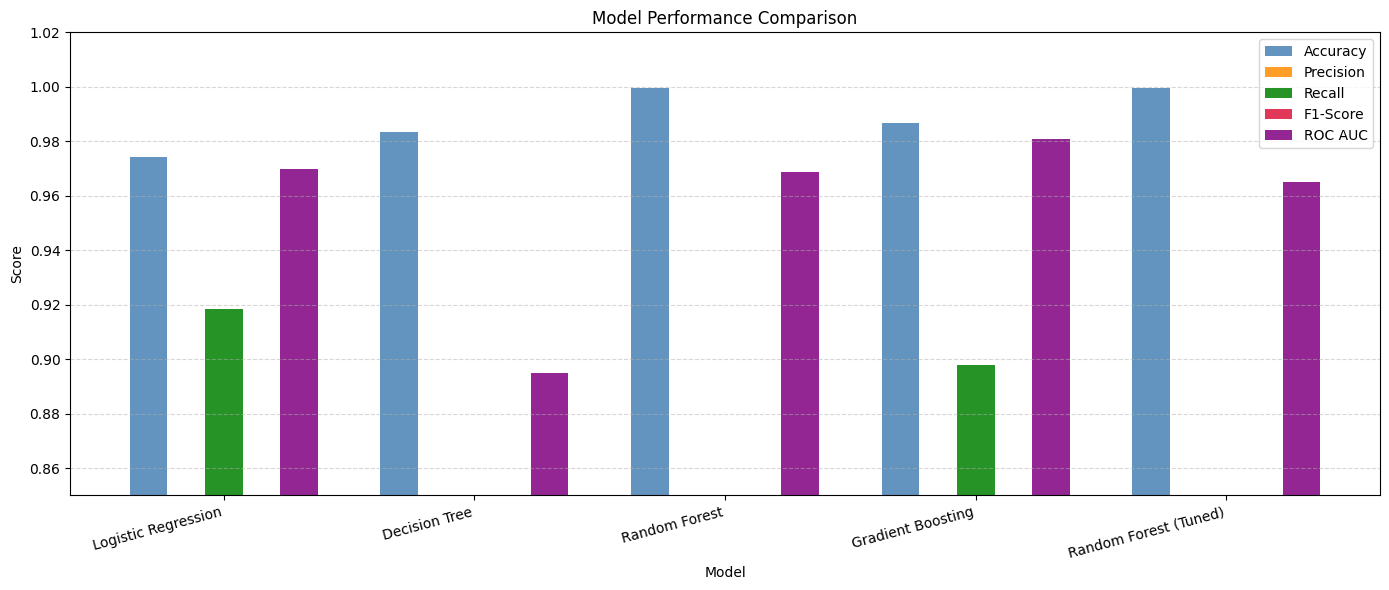

In [ ]:
# Bar Chart Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=colors[i], alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

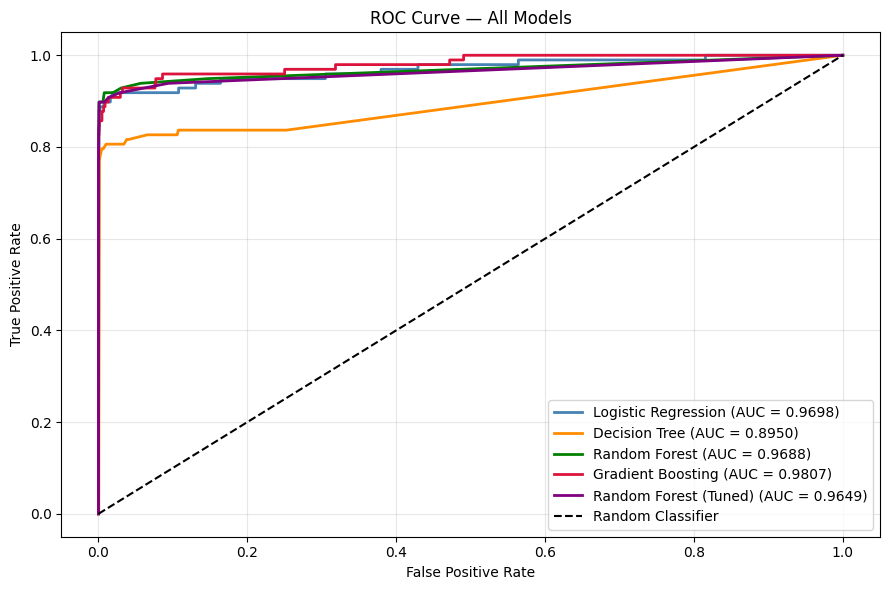

In [ ]:
# ROC Curve for All Models
plt.figure(figsize=(9, 6))

line_colors = ['steelblue', 'darkorange', 'green', 'crimson', 'purple']

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    plt.plot(fpr, tpr, color=line_colors[i],
             label=f"{r['Model']} (AUC = {r['ROC AUC']:.4f})", lw=2)

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

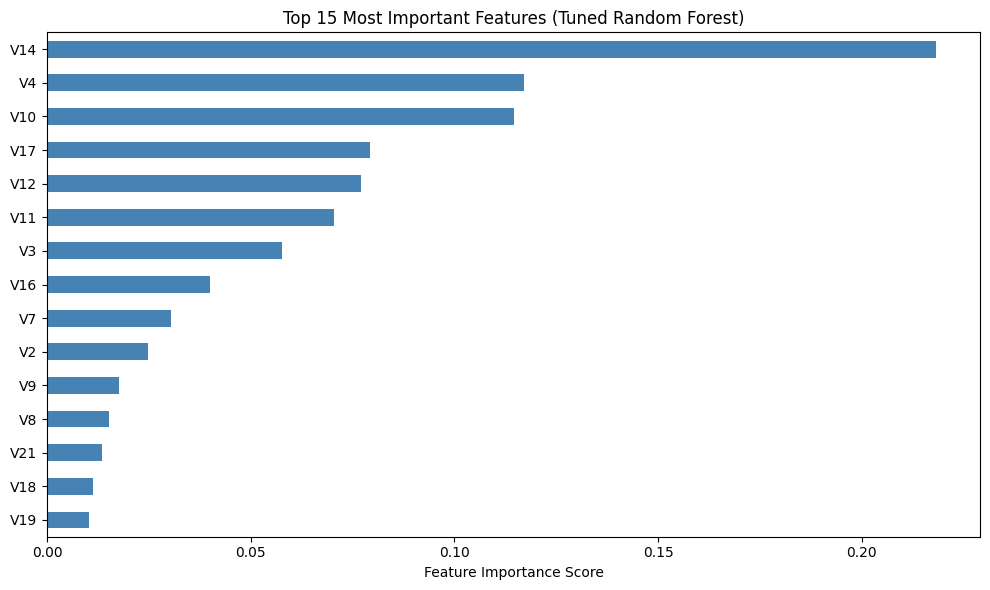

In [ ]:
# Feature Importance (Best Model)
# Show which features matter most for fraud detection

best_model = best_rf  # Use the tuned Random Forest
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features (Tuned Random Forest)')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()